In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

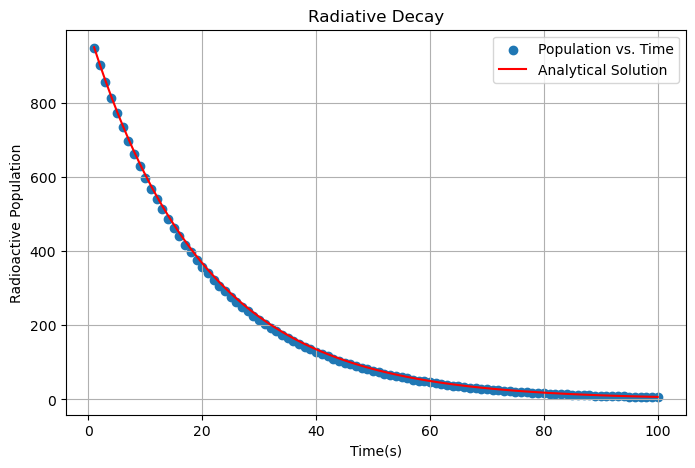

In [26]:
N0 = 1000
lam = 0.05
dt = 1.0 #'min'
#dt= 1.0* (10* np.exp(-12)) #'min'
t_total = 100 #'min'

N = N0 #I don't 100% get what this does

N_list = []
t_list = []
#lam_list = []
#dt_list = []

t = 0.0
while t < t_total: 
    slope = -lam * N
    dN = slope * dt

    N += dN #or this
    t += dt #and this

    t_list.append(t)
    N_list.append(N)

t_array = np.array(t_list)
N_sim = N0 * np.exp(-lam * t_array)

plt.figure(figsize=(8,5))
plt.scatter(t_list, N_list, label = 'Population vs. Time')
plt.plot(t_array, N_sim, color = 'red', label = 'Analytical Solution')
plt.title('Radiative Decay')
plt.xlabel('Time(s)')
plt.ylabel('Radioactive Population')
plt.legend()
plt.grid()
plt.show()

#The simulation slightly overestimates the decay data.



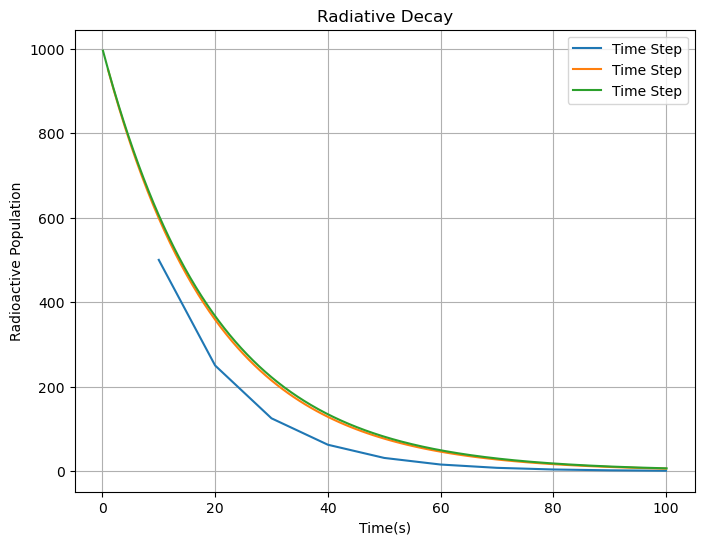

In [25]:
N0 = 1000
lam = 0.05
t_total = 100 #'min'


def euler_decay(dt):
    t = 0.0
    N = N0
    N_list = []
    t_list = []
#lam_list = []
#dt_list = []
    while t < t_total:
        slope = -lam * N
        dN = slope * dt
        N += dN
        t += dt
        t_list.append(t)
        N_list.append(N)
        
    return np.array(t_list), np.array(N_list)

dts = [10, 1.0, 0.1] #'min'
colors = ['green', 'red', 'blue']

plt.figure(figsize=(8,6))

for i in range(len(dts)):
    dt = dts[i]
    c = colors[i]
    t_step, N_step = euler_decay(dt)
    plt.plot(t_step, N_step, label = 'Time Step')

plt.title('Radiative Decay')
plt.xlabel('Time(s)')
plt.ylabel('Radioactive Population')
plt.legend()
plt.grid()
plt.show()

#The value of dt steps could easily overshoot or undershoot the correct data points.
#If the time steps are too small, the graph gets muddled with data points, making it difficult to see the true curve fit.

    

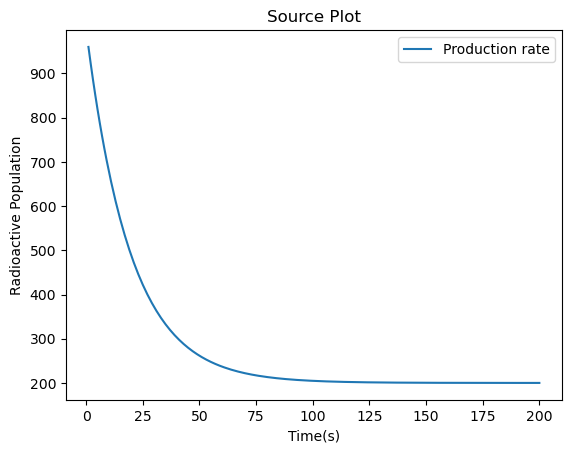

The population reaches a steady rate at: 200.028


In [4]:
#dN/dt = P - lam*N
P = 10 #'nuclei/min'
N0 = 1000
lam = 0.05
dt = 1.0 #'min'
t_max = 200 #'min'

t = 0.0
N = N0

N_source = []
t_source = []

while t < t_max:
    slope = P -lam * N
    dN = slope * dt
    N += dN
    t += dt
    t_source.append(t)
    N_source.append(N)

plt.plot(t_source, N_source, label= 'Production rate')
plt.title('Source Plot')
plt.xlabel('Time(s)')
plt.ylabel('Radioactive Population')
plt.legend()
plt.show()

def source_fun(t, N, P, lam):
    N = -(lam/dt) * dN + (P/lam)

print(f'The population reaches a steady rate at: {N:.3f}')


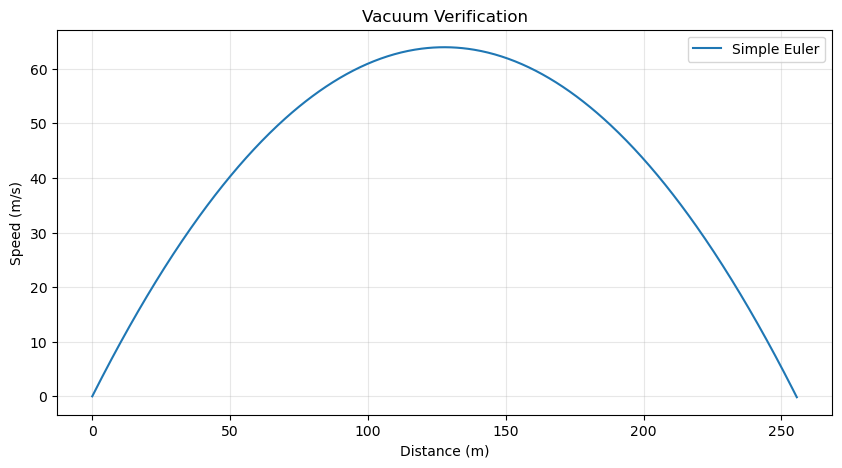

Simulated landing distance: 255.61910139893868
Theoretical Range: 255.1020408163265


In [5]:
m= 1.0
b= 0.0
v= 50 #m/s
g= 9.8 #m/s^2
dt= 0.01

theta = np.radians(45)
pos = np.array([0.0, 0.0])    # [x, y]
vel = np.array([v*np.cos(theta), v*np.sin(theta)])


x_vac = [pos[0]]
y_vac = [pos[1]]

vx = [vel[0]]
vy= [vel[1]]

while pos[1] >= 0 :
    #f_net = f_g + f_drag
    a = np.array([0.0, -g]) - (b/m)*v
    pos = pos + vel*dt
    vel = vel + a*dt

    x_vac.append(pos[0])
    y_vac.append(pos[1])
    
    vx.append(vel[0])
    vy.append(vel[1])



plt.figure(figsize=(10, 5))
plt.plot(x_vac, y_vac, label='Simple Euler')


plt.xlabel("Distance (m)")
plt.ylabel("Speed (m/s)")
plt.title("Vacuum Verification")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

landing_distance = x_vac[-1]
print("Simulated landing distance:", landing_distance)

R = (v**2 * np.sin(2*theta))/g
print("Theoretical Range:", R)

#The simulation is overshooting.


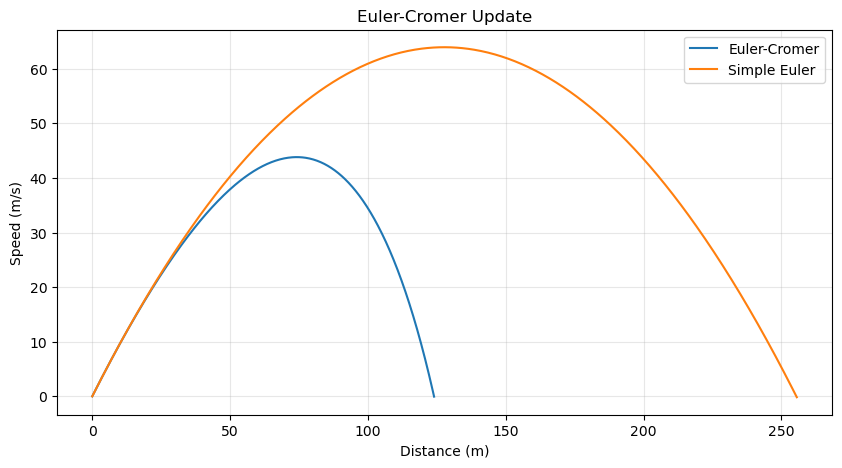

In [6]:
m= 1.0
b= 0.2
v= 50 #m/s
g= 9.8 #m/s^2
dt= 0.01

theta = np.radians(45)
pos = np.array([0.0, 0.0])    # [x, y]
vel = np.array([v*np.cos(theta), v*np.sin(theta)])


x = [pos[0]]
y = [pos[1]]

vx = [vel[0]]
vy= [vel[1]]

while pos[1] >= 0 :
    #f_net = f_g + f_drag
    a = np.array([0.0, -g]) - (b/m)*vel
    pos = pos + vel*dt
    vel = vel + a*dt

    x.append(pos[0])
    y.append(pos[1])
    vx.append(vel[0])
    vy.append(vel[1])



plt.figure(figsize=(10, 5))
plt.plot(x, y, label='Euler-Cromer')
plt.plot(x_vac, y_vac, label='Simple Euler')
plt.xlabel("Distance (m)")
plt.ylabel("Speed (m/s)")
plt.title("Euler-Cromer Update")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
#The air resistance slightly affects the symmetry of the arc. Shifting it more to the right.

Optimal angle: 34.29 degrees
Max range: 129.32 m


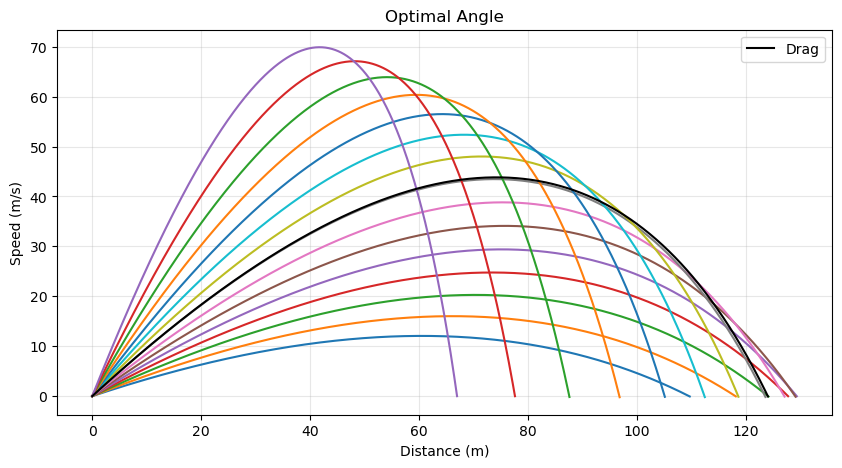

In [7]:
m= 1.0
b= 0.2
v= 50 #m/s
g= 9.8 #m/s^2
dt= 0.01

angle1= 20 * np.pi/180
angle2= 70 * np.pi/180
d_theta = np.linspace(angle1, angle2, 15)
theta_store= []

plt.figure(figsize=(10, 5))

for theta in d_theta:
    pos = np.array([0.0, 0.0])    # [x, y] 
    vel = np.array([v*np.cos(theta), v*np.sin(theta)])
   
    x_oa = [pos[0]]
    y_oa = [pos[1]]
    
    vx = [vel[0]]
    vy= [vel[1]]
    
    while pos[1] >= 0 :
    #f_net = f_g + f_drag
        a = np.array([0.0, -g]) - (b/m)*vel
        vel = vel + a*dt
        pos = pos + vel*dt

        x_oa.append(pos[0])
        y_oa.append(pos[1])
        #vx.append(vel[0])
        #vy.append(vel[1])
    theta_store.append(pos[0])
    
    plt.plot(x_oa, y_oa)

idx_max = np.argmax(theta_store)
theta_opt = d_theta[idx_max]
delta_opt = theta_store[idx_max]

print(f"Optimal angle: {theta_opt*180/np.pi:.2f} degrees")
print(f"Max range: {delta_opt:.2f} m")


#plt.figure(figsize=(10, 5))
plt.plot(x, y, label='Drag', color= 'black')
#plt.plot(x_eu, y_eu, label='Air Resistance')
plt.xlabel("Distance (m)")
plt.ylabel("Speed (m/s)")
plt.title("Optimal Angle")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



'k'

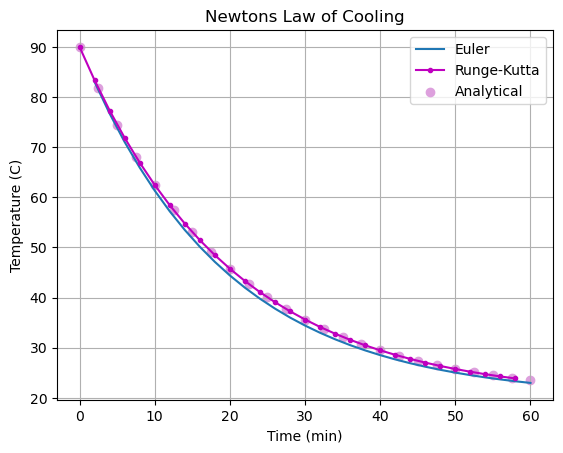

In [24]:
T = 90
T_env = 20
k = 0.05
dt = 2.0
t_f = 60
t = 0

t_list = []
T_list = []

while t < t_f:
    dT = -k * (T - T_env)*dt
    T = T + dT
    t += dt

    t_list.append(t)
    T_list.append(T)
plt.plot(t_list, T_list, label= 'Euler')

T2 = 90
T2_env = 20
k = 0.05
dt2 = 2.0
t2_f = 60
t2 = 0

def f_rk4(f, t2, y, dt2):
    k1 = f(t2, y)
    k2 = f(t2+0.5*dt2, y+0.5*dt2*k1)
    k3 = f(t2+0.5*dt2, y+0.5*dt2*k2)
    k4 = f(t2+dt2, y+dt2*k3)

    return y + dt*(k1 + 2*k2 + 2*k3 + k4)/6

def T_change(t2,T2):
    return -k * (T2 - T2_env)


results= []
while t2 < t2_f:
    results.append([t2, T2])
    T2 = f_rk4(T_change, t2, T2, dt2)
    t2 += dt2
results= np.array(results)
plt.plot(results[:,0], results[:,1], 'm.-', label='Runge-Kutta')

t3_list= np.linspace(0,60,25)
T0= 90
T3= T2_env + (T0 - T2_env)*((np.e)**(-k*t3_list))

plt.scatter(t3_list, T3, color = 'plum', label = 'Analytical')
plt.title('Newtons Law of Cooling')
plt.xlabel('Time (min)')
plt.ylabel('Temperature (C)')
plt.legend()
plt.grid()



'''The Runge-Kutta method is closer to the exact solution.
At the fist 10 minutes, the Euler method shifts approximately 2-4% degrees
